In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('./files/cleaned_dataset.csv')

In [2]:
df.head()

,Book Name,Author,Rating,Number of Reviews,Price,Description,Listening Time (minutes),Genre,Rank
0,Think Like a Monk: The Secret of How to Harnes...,Jay Shetty,4.9,313,10080.0,"Over the past three years, Jay Shetty has beco...",654.0,Personal Success,1
1,Ikigai: The Japanese Secret to a Long and Happ...,Héctor García,4.6,3658,615.0,Brought to you by Penguin.,203.0,Meditation,1
2,The Subtle Art of Not Giving a F*ck: A Counter...,Mark Manson,4.4,20174,10378.0,"In this generation-defining self-help guide, a...",317.0,Personal Success,3
3,Atomic Habits: An Easy and Proven Way to Build...,James Clear,4.6,4614,888.0,Brought to you by Penguin.,335.0,Psychology,1
4,Life's Amazing Secrets: How to Find Balance an...,Gaur Gopal Das,4.6,4302,1005.0,"Stop going through life, Start growing throug...",385.0,Literary Essays,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3025 entries, 0 to 3024
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Book Name                 3025 non-null   object 
 1   Author                    3025 non-null   object 
 2   Rating                    3025 non-null   float64
 3   Number of Reviews         3025 non-null   int64  
 4   Price                     3025 non-null   float64
 5   Description               3025 non-null   object 
 6   Listening Time (minutes)  3025 non-null   float64
 7   Genre                     3025 non-null   object 
 8   Rank                      3025 non-null   int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 212.8+ KB


# 1) Distribution of ratings across genres

In [33]:
# Calculate the distribution of ratings across genres

rating_distribution = df.groupby('Genre')['Rating'].mean().reset_index()

In [34]:
# Sort genres by average rating

rating_distribution = rating_distribution.sort_values(by='Rating', ascending=False)

In [35]:
# Select top 10 genres (you can adjust this number based on your dataset)

top_genres = rating_distribution.head(10)

top_genres

,Genre,Rating
300,History of Science,5.0
272,German Language Learning,5.0
116,Christian Ministry & Evangelism,5.0
541,Superhero Fiction for Teens,5.0
524,Spanish Language Learning,5.0
531,Sports & Outdoors,5.0
342,Language Learning,5.0
345,Law History,5.0
566,Triathlon,5.0
132,Colonialism & Post-Colonialism,5.0


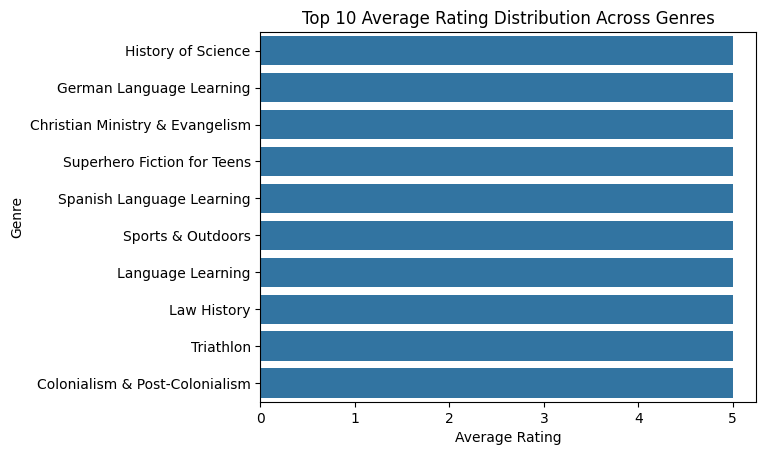

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x='Rating', y='Genre', data=top_genres)
plt.title('Top 10 Average Rating Distribution Across Genres')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

# 2) Most common Genres

In [19]:
# Count the frequency of each genre
genre_counts = df['Genre'].value_counts().head(10).reset_index()

genre_counts

,Genre,count
0,Religion & Philosophy,669
1,Fantasy,399
2,Personal Success,75
3,Contemporary Romance,28
4,Literary Fiction,26
5,Indian Literature,23
6,Classic Literature,22
7,Meditation,22
8,Contemporary Fiction,20
9,Leadership,20


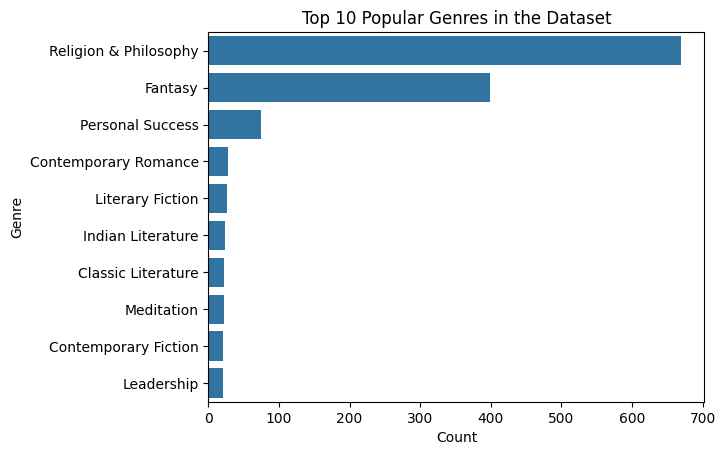

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x='count', y='Genre', data=genre_counts)
plt.title('Top 10 Popular Genres in the Dataset')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

# 3) Relationship between book ratings and review counts

In [23]:
df.corr(numeric_only=True)

,Rating,Number of Reviews,Price,Listening Time (minutes),Rank
Rating,1.000000,0.065333,0.031961,-0.020687,-0.014544
Number of Reviews,0.065333,1.000000,0.086093,0.083138,-0.104442
Price,0.031961,0.086093,1.000000,0.060225,-0.028940
Listening Time (minutes),-0.020687,0.083138,0.060225,1.000000,-0.614892
Rank,-0.014544,-0.104442,-0.028940,-0.614892,1.000000


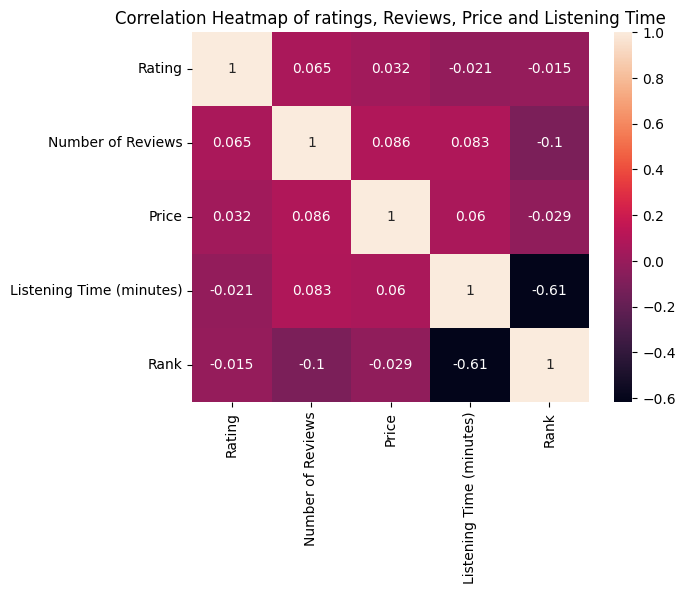

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap of ratings, Reviews, Price and Listening Time')
plt.show()

# 4) What are the most popular genres in the dataset?

In [28]:
df['Genre'].value_counts().reset_index().head(10)

,Genre,count
0,Religion & Philosophy,669
1,Fantasy,399
2,Personal Success,75
3,Contemporary Romance,28
4,Literary Fiction,26
5,Indian Literature,23
6,Classic Literature,22
7,Meditation,22
8,Contemporary Fiction,20
9,Leadership,20


5) Which authors have the highest-rated books

In [38]:
df.groupby('Author')['Rating'].mean().reset_index().sort_values(by='Rating', ascending=False).head(10)

,Author,Rating
2042,Vella Day,5.0
691,Gianna Gabriela,5.0
2040,Vasant Lad,5.0
2083,Werner Heidemann,5.0
484,Deva Premal,5.0
478,Dennis Clark,5.0
753,Heidi Lemon,5.0
719,Gregory R. Lanier,5.0
731,H. S. Panag,5.0
380,Cyndi Dale,5.0


# 5) What is the average rating Distribution across books?

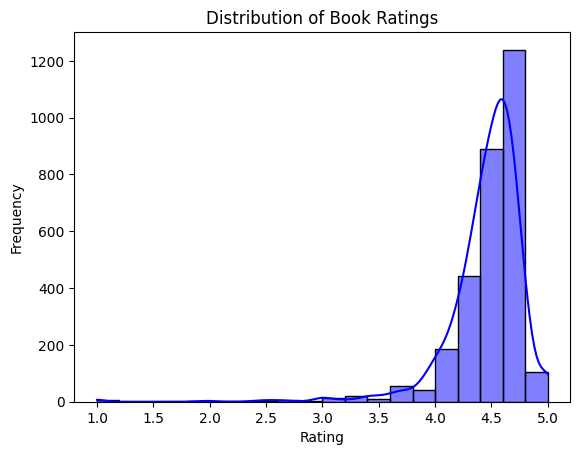

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Rating'], kde=True, color='blue', bins=20)
plt.title('Distribution of Book Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# 6) How do ratings vary between books with different review counts?

In [43]:
bins = [0, 50, 200, 500, 1000, 5000, 20000, df['Number of Reviews'].max()]
labels = ['0-50', '51-200', '201-500', '501-1000', '1001-5000', '5001-20000', '20001+']

df['Review Count Range'] = pd.cut(df['Number of Reviews'], bins=bins, labels=labels)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4180\3423383977.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Review Count Range', y='Rating', data=df, palette='Set2')


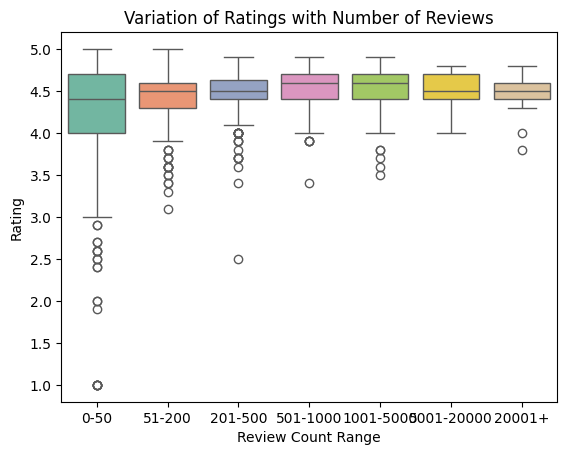

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x='Review Count Range', y='Rating', data=df, palette='Set2')
plt.title('Variation of Ratings with Number of Reviews')
plt.xlabel('Review Count Range')
plt.ylabel('Rating')
plt.show()